# Credit Card Fraud Detection: Complete Exploratory Data Analysis

---

# 1. Introduction

Credit card fraud is a critical challenge for financial institutions worldwide. This dataset contains **55,000 synthetic credit card transactions** with rich behavioral, demographic, and transactional features. Our goal is to deeply understand the data, uncover patterns that distinguish fraudulent transactions, and prepare it for robust modeling.

**Business Impact**: Early fraud detection can save millions in losses while maintaining customer trust.

**What makes this notebook special**:
- Beautiful visualizations with Seaborn + Matplotlib
- Interactive insights
- Actionable business recommendations
- Ready-to-use code for Kaggle/Portfolio

### Import Libraries

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Load the dataset

In [5]:
df = pd.read_csv('credit_card_fraud_dataset.csv')
print(f"Dataset loaded with shape: {df.shape}")
df.head()

Dataset loaded with shape: (55000, 29)


,transaction_id,customer_id,age,occupation,annual_income_usd,credit_limit_usd,credit_score,account_age_months,transaction_date,transaction_hour,...,card_present,cvv_mismatch,device_changed,avg_monthly_spend_usd,num_transactions_last_30d,velocity_last_1h,failed_attempts_last_24h,credit_utilization_pct,prev_fraud_flags,is_fraud
0,TXN1042337,CUST79495,46,Sales Rep,61141,51651,466,69,2023-02-23,16,...,1,0,0,4248,37,2,0,0.1,0,0
1,TXN1006835,CUST72067,61,Retired,58971,21396,652,140,2023-06-18,8,...,1,0,0,6139,40,1,0,4.6,0,0
2,TXN1044571,CUST54867,22,Doctor,144697,130967,681,50,2023-07-06,18,...,1,0,0,9083,30,1,0,0.3,0,0
3,TXN1019584,CUST22363,57,Nurse,75822,86294,695,188,2023-10-04,1,...,1,0,0,10599,45,2,0,1.4,0,0
4,TXN1043336,CUST49581,75,Teacher,43542,34726,702,197,2023-02-04,7,...,1,0,0,7219,34,1,0,1.1,0,0


# 2. Dataset Overview

In [6]:
# Basic Information
print("Dataset Information:")
print(f"Total Transactions: {len(df):,}")
print(f"Features: {df.shape[1]}")
print(f"Fraud Rate: {(df['is_fraud'].mean()*100):.2f}%")

print("\nMissing Values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values!")

print("\nData Types:")
print(df.dtypes.value_counts())

Dataset Information:
Total Transactions: 55,000
Features: 29
Fraud Rate: 3.77%

Missing Values:
No missing values!

Data Types:
int64      19
object      8
float64     2
Name: count, dtype: int64


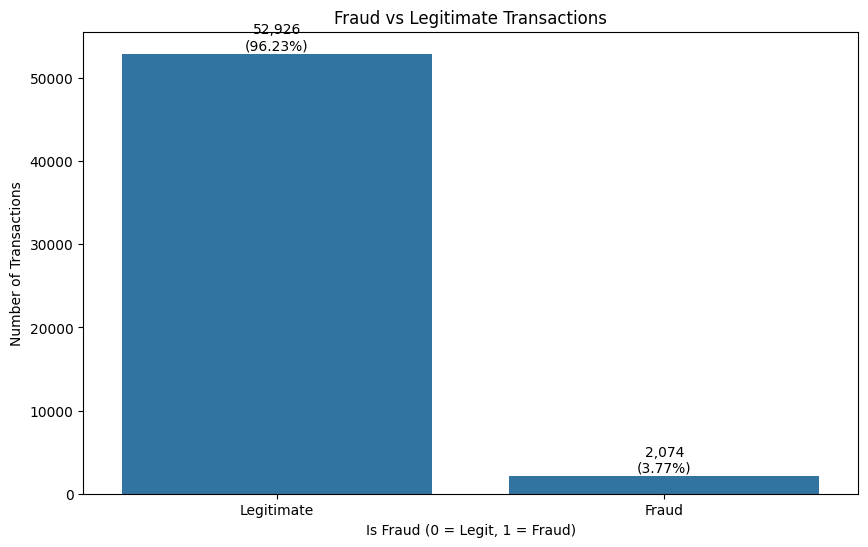

In [8]:
# Target Variable Distribution
plt.figure(figsize=(10, 6))
fraud_counts = df['is_fraud'].value_counts()
ax = sns.barplot(x=fraud_counts.index, y=fraud_counts.values)
plt.title('Fraud vs Legitimate Transactions')
plt.xlabel('Is Fraud (0 = Legit, 1 = Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])

for i, v in enumerate(fraud_counts):
    ax.text(i, v + 500, f"{v:,}\n({v/len(df)*100:.2f}%)", ha='center')

plt.show()

# 3. Data Cleaning & Preprocessing

In [9]:
# Convert date
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Create useful time features
df['transaction_day'] = df['transaction_date'].dt.dayofweek
df['transaction_month'] = df['transaction_date'].dt.month
df['is_weekend'] = df['transaction_day'].isin([5, 6]).astype(int)

print("New time-based features created!")
df[['transaction_date','transaction_hour', 'is_weekend']].head()

New time-based features created!


,transaction_date,transaction_hour,is_weekend
0,2023-02-23,16,0
1,2023-06-18,8,1
2,2023-07-06,18,0
3,2023-10-04,1,0
4,2023-02-04,7,1


# 4. Univariate Analysis

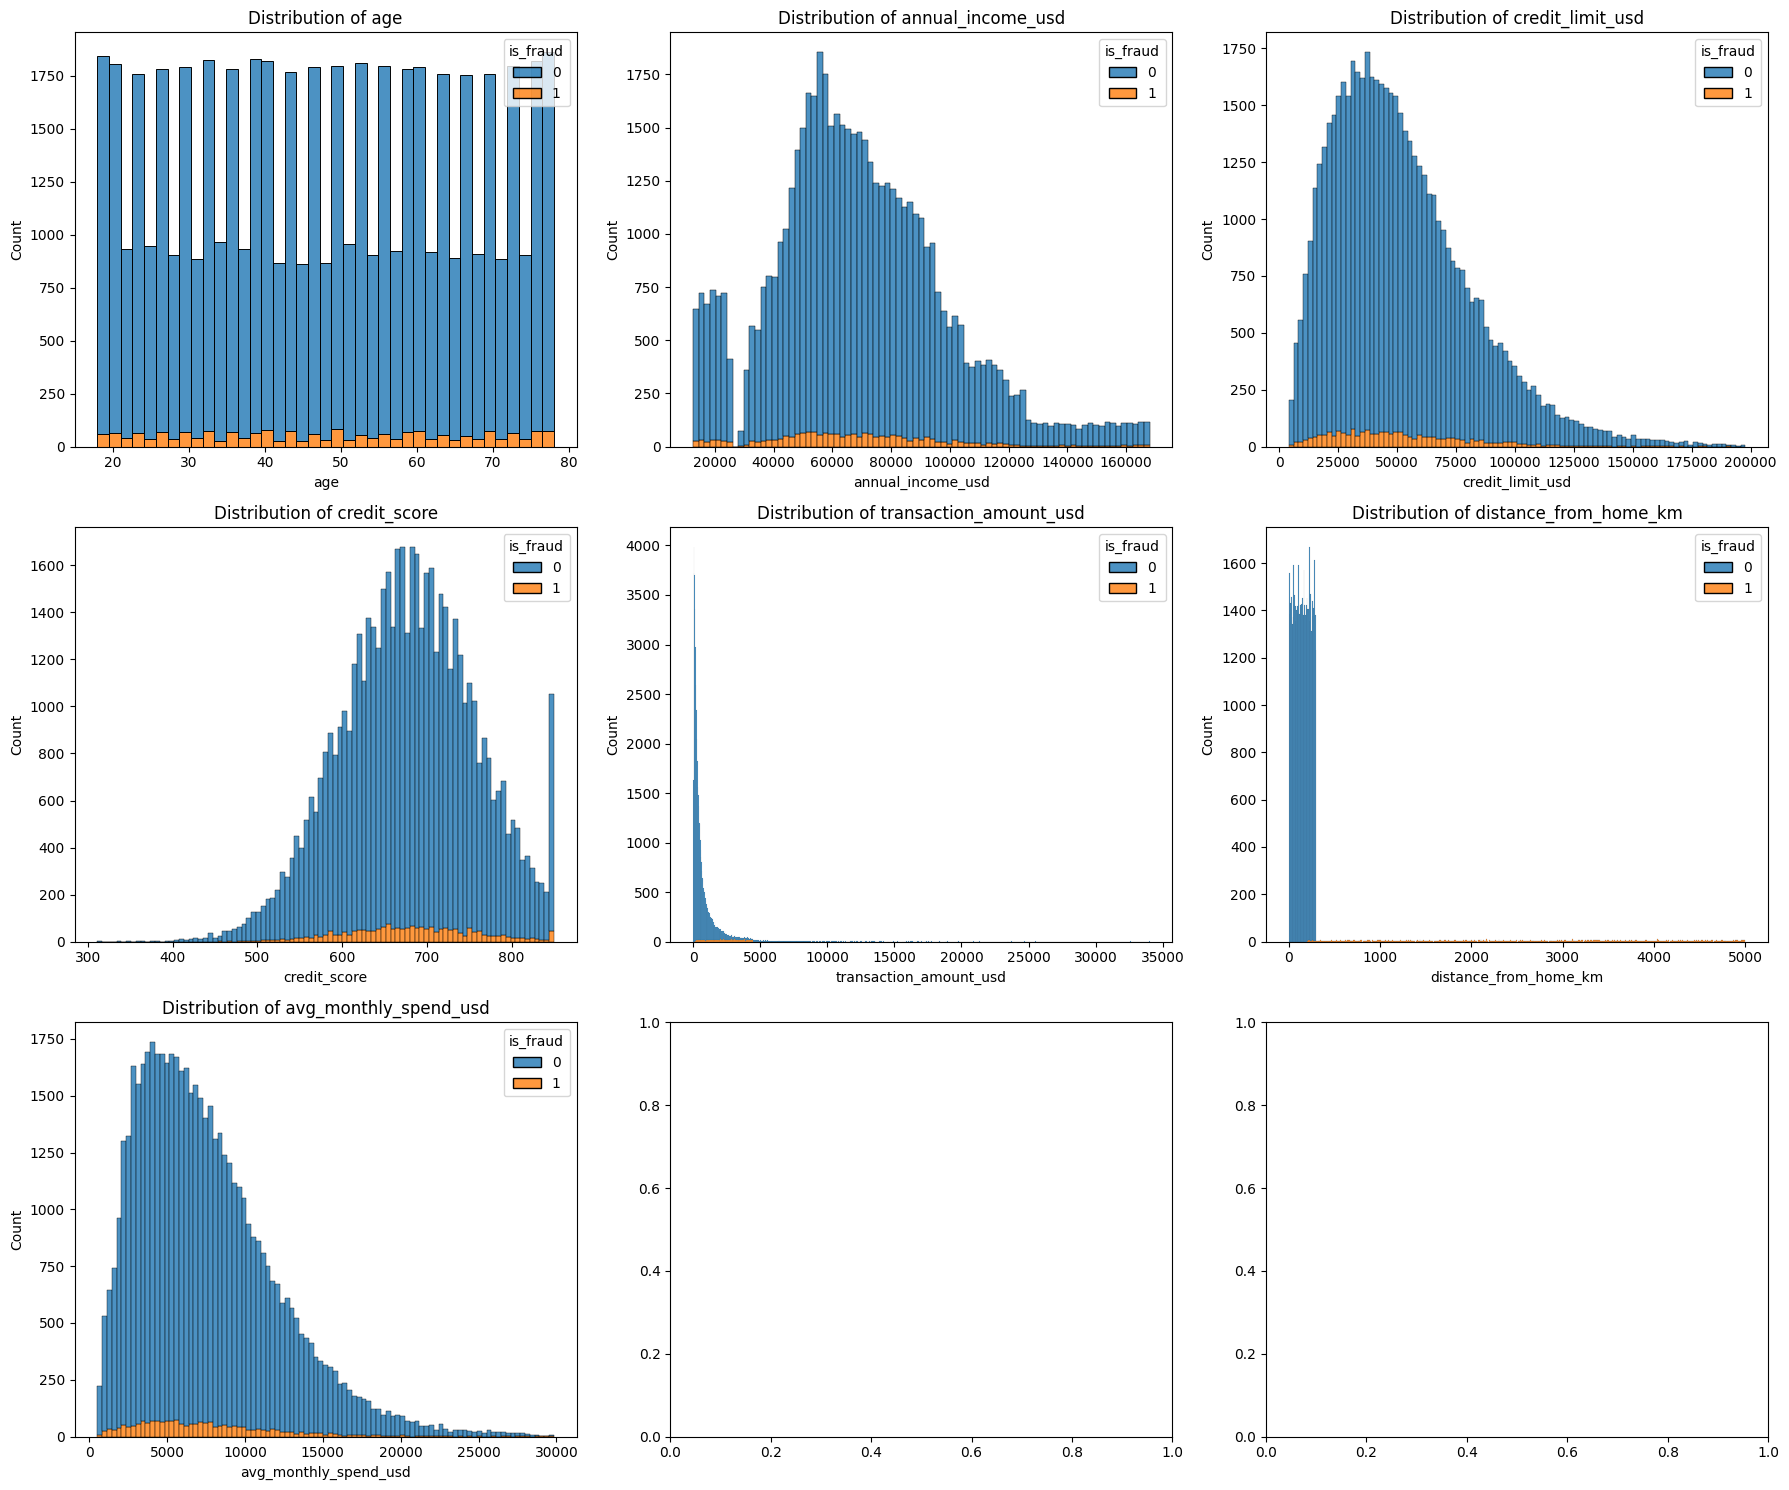

In [10]:
# Numerical Features Distributions
numerical_cols = ['age', 'annual_income_usd', 'credit_limit_usd', 'credit_score',
                 'transaction_amount_usd', 'distance_from_home_km', 'avg_monthly_spend_usd']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, hue='is_fraud', multiple="stack", ax=axes[i], alpha=0.8)
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

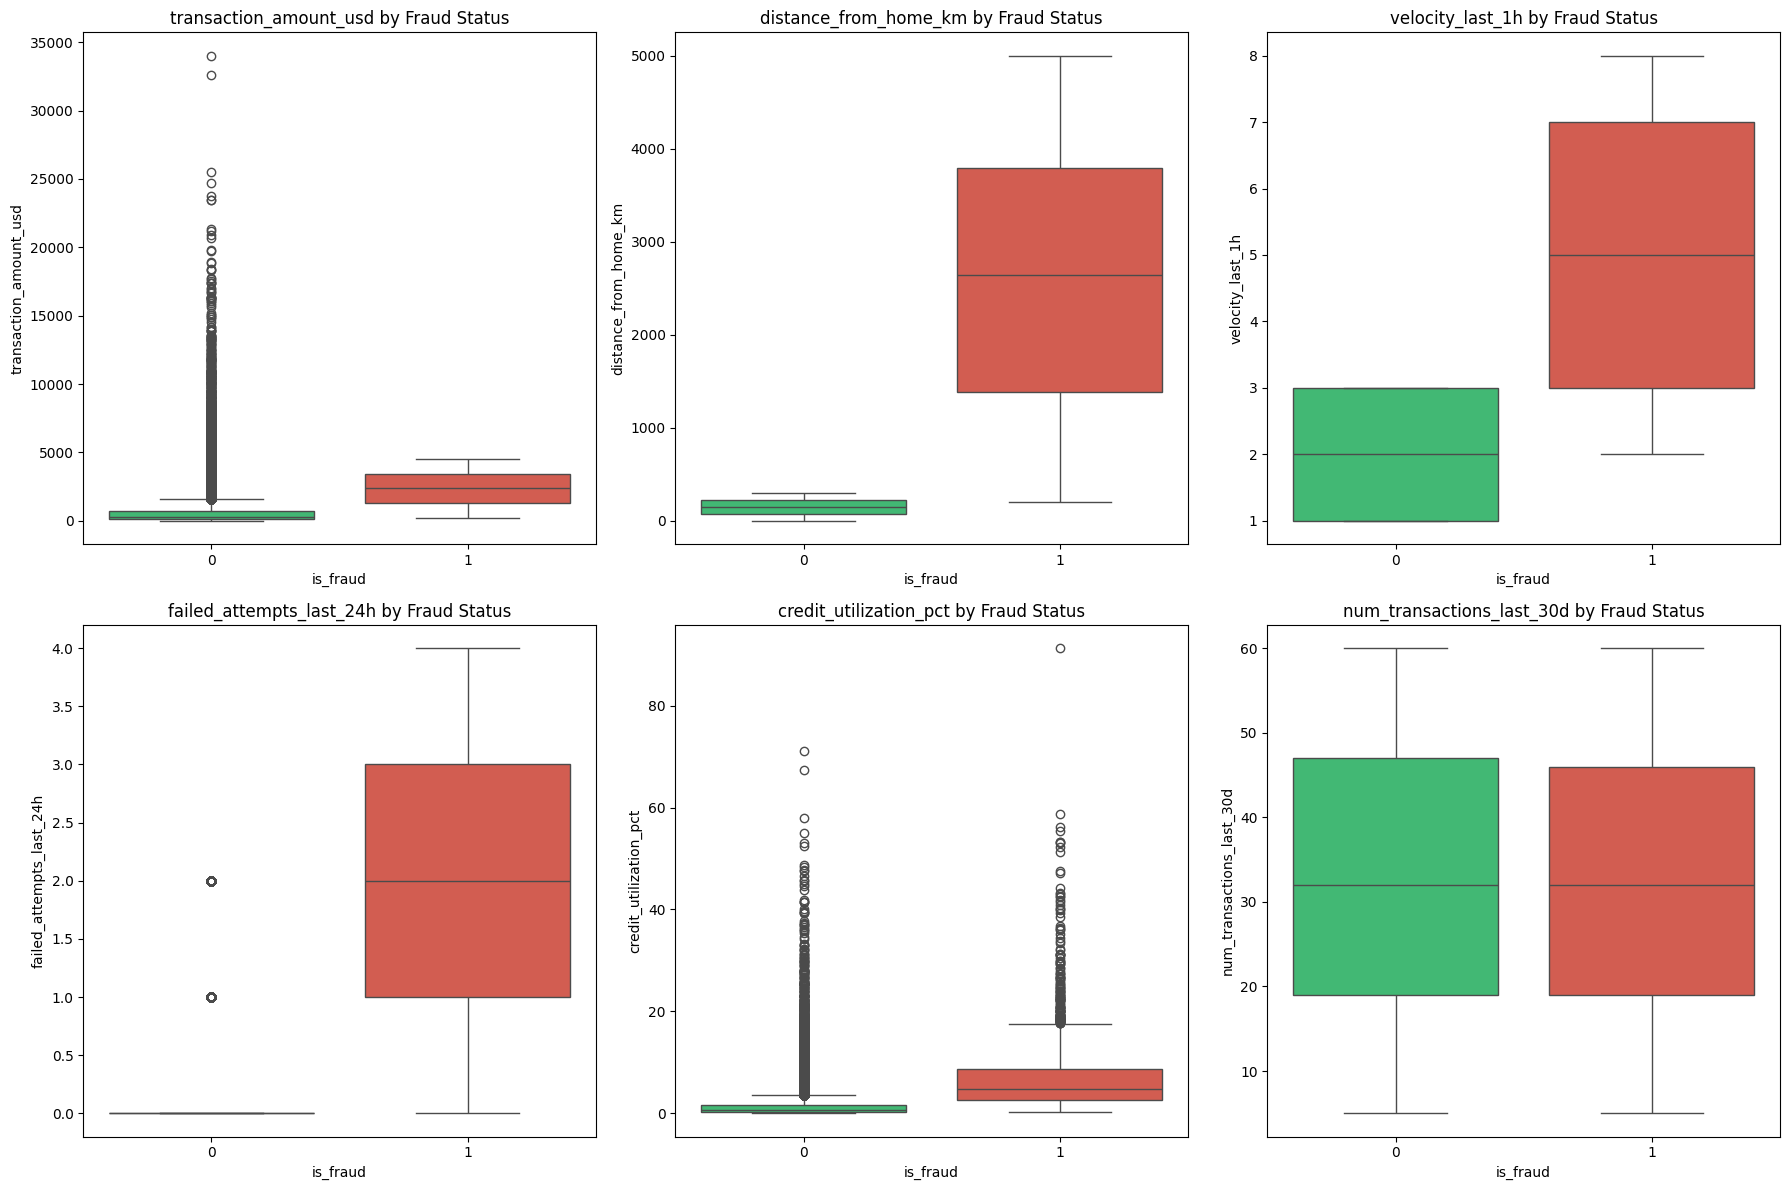

In [11]:
# Boxplots for Outlier Detection (Fraud vs Non-Fraud)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
key_features = ['transaction_amount_usd', 'distance_from_home_km', 'velocity_last_1h',
               'failed_attempts_last_24h', 'credit_utilization_pct', 'num_transactions_last_30d']

for i, col in enumerate(key_features):
    sns.boxplot(data=df, x='is_fraud', y=col, ax=axes[i//3, i%3],
               palette=['#2ecc71', '#e74c3c'])
    axes[i//3, i%3].set_title(f'{col} by Fraud Status')

plt.tight_layout()
plt.show()

# 5. Bivariate & Multivariate Analysis

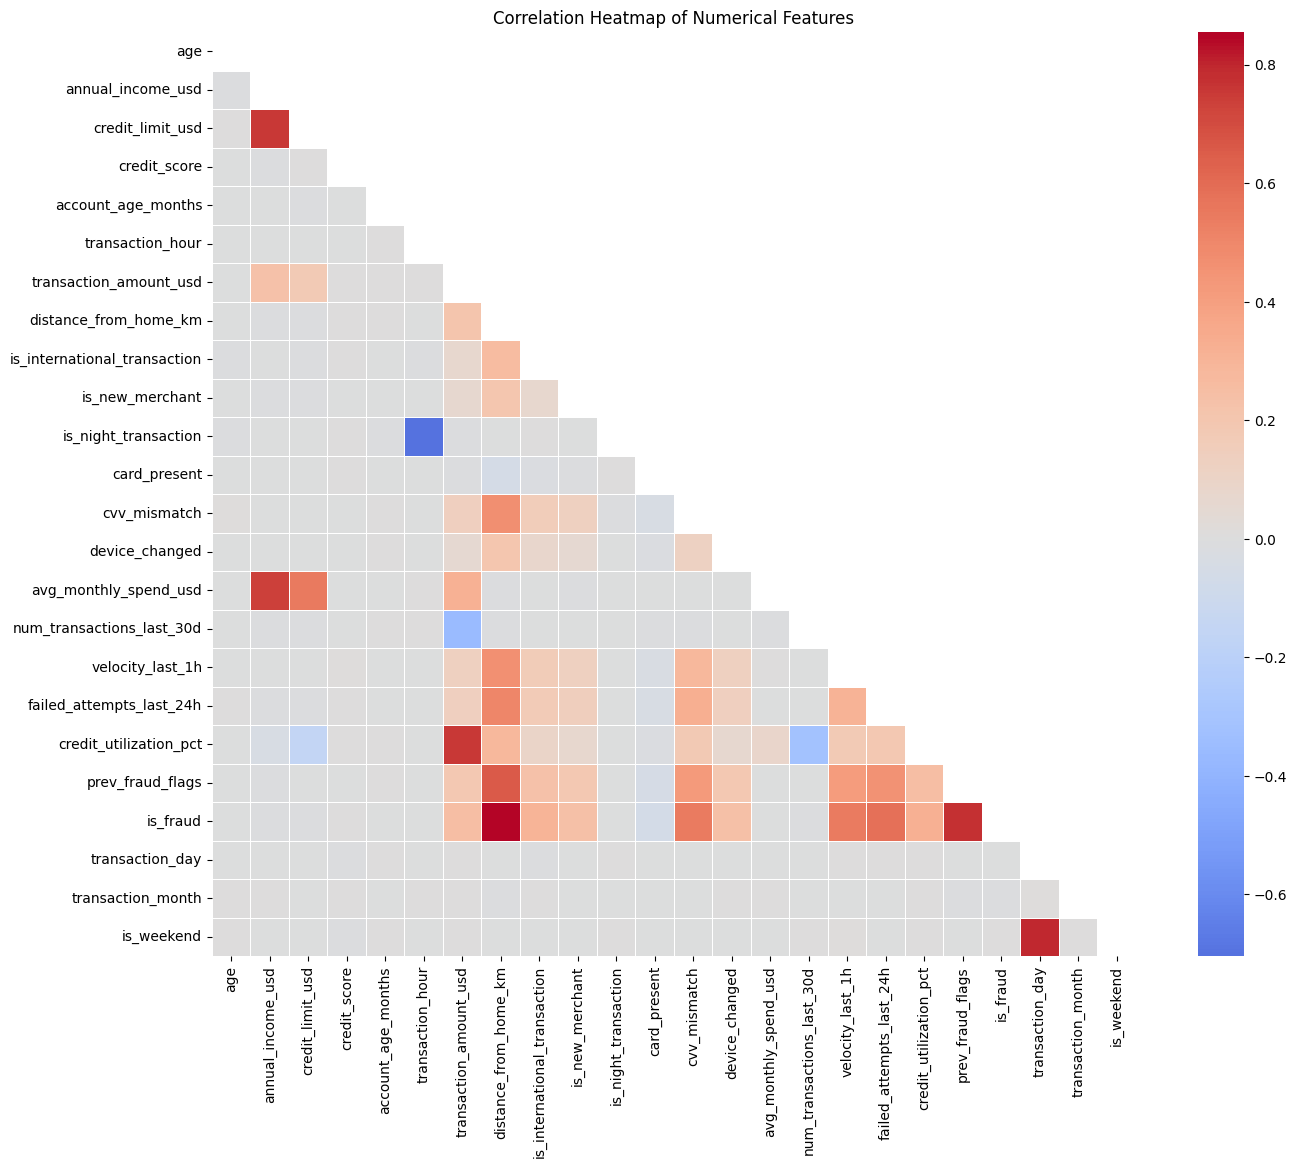

In [12]:
# Correlation Heatmap
plt.figure(figsize=(16, 12))
corr = df.select_dtypes(include=np.number).corr()

# Mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            linewidths=0.5, center=0, square=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

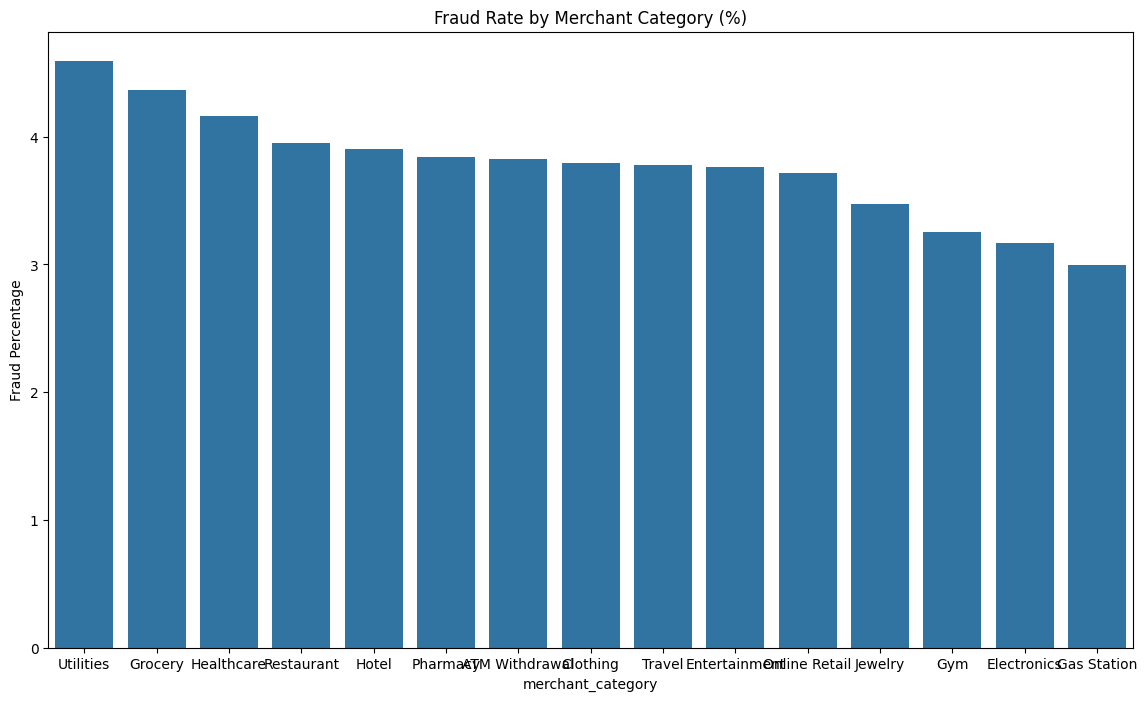

In [13]:
# High-Risk Merchant Categories
plt.figure(figsize=(14, 8))
merchant_fraud = df.groupby('merchant_category')['is_fraud'].agg(['mean', 'count']).sort_values('mean', ascending=False)
merchant_fraud = merchant_fraud[merchant_fraud['count'] > 50]

sns.barplot(x=merchant_fraud.index, y=merchant_fraud['mean']*100)
plt.title('Fraud Rate by Merchant Category (%)')
plt.ylabel('Fraud Percentage')
plt.show()

<Figure size 1200x600 with 0 Axes>

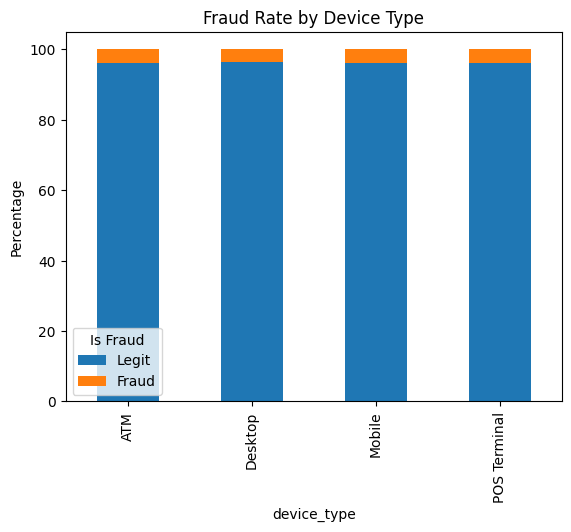

In [14]:
# Device Type Analysis
plt.figure(figsize=(12, 6))
device_fraud = pd.crosstab(df['device_type'], df['is_fraud'], normalize='index') * 100

device_fraud.plot(kind='bar', stacked=True)
plt.title('Fraud Rate by Device Type')
plt.ylabel('Percentage')
plt.legend(title='Is Fraud', labels=['Legit', 'Fraud'])
plt.show()

# 6. Fraud Pattern Deep Dive

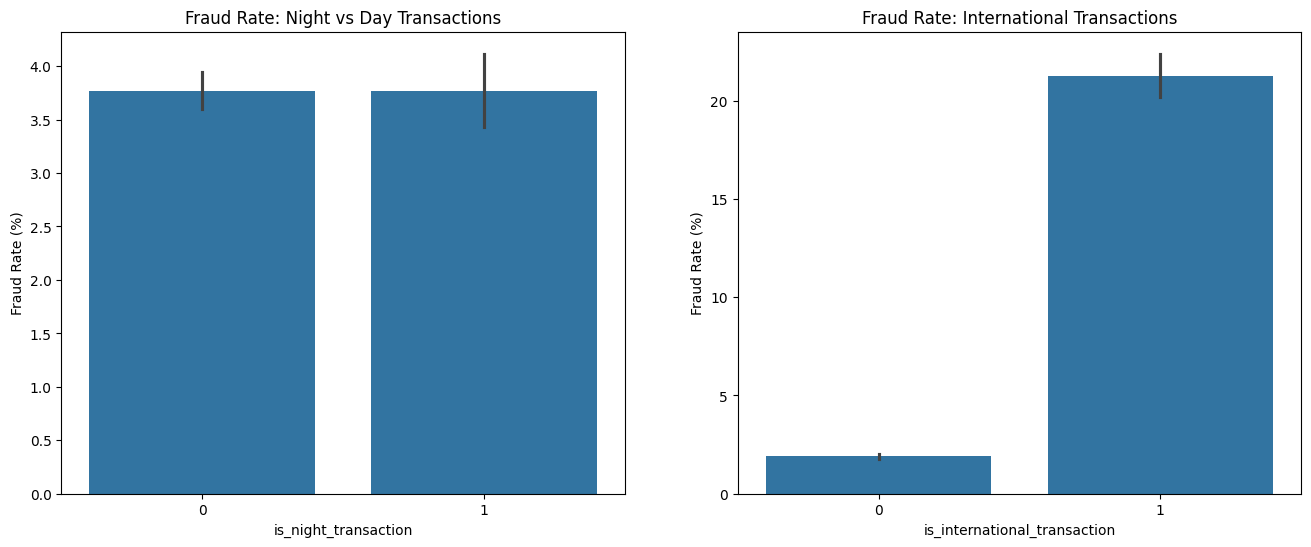

In [15]:
# Night Transactions & International
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='is_night_transaction', y='is_fraud', data=df, ax=axes[0],
           estimator=lambda x: sum(x)/len(x)*100)
axes[0].set_title('Fraud Rate: Night vs Day Transactions')
axes[0].set_ylabel('Fraud Rate (%)')

sns.barplot(x='is_international_transaction', y='is_fraud', data=df, ax=axes[1],
           estimator=lambda x: sum(x)/len(x)*100)
axes[1].set_title('Fraud Rate: International Transactions')
axes[1].set_ylabel('Fraud Rate (%)')

plt.show()

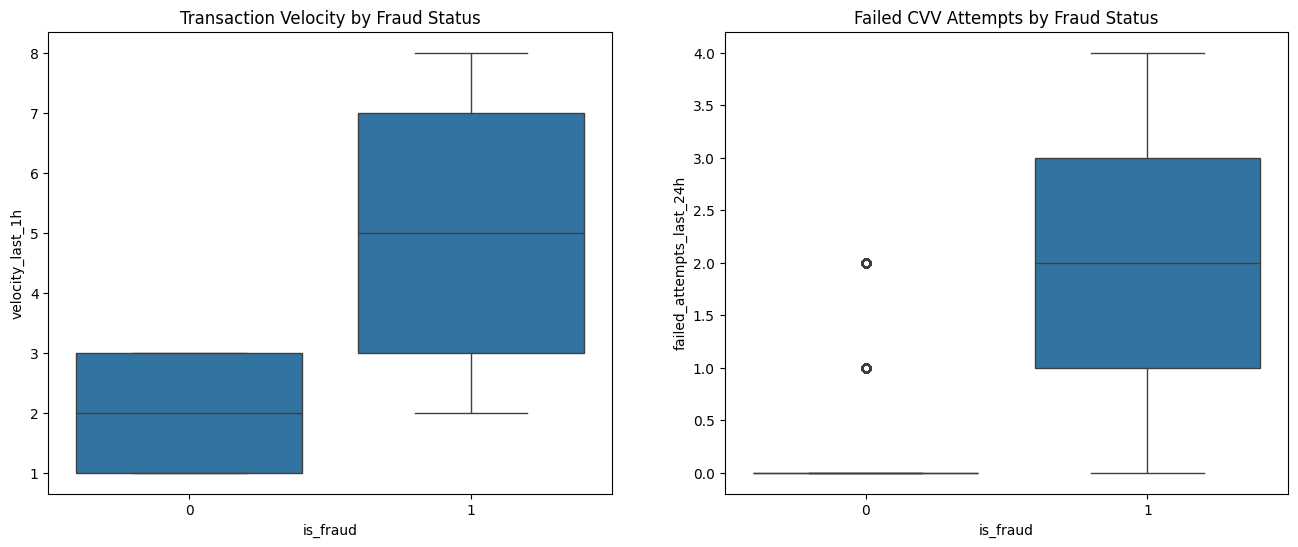

In [16]:
# Velocity & Failed Attempts - Strong Fraud Signals
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='is_fraud', y='velocity_last_1h', data=df, ax=axes[0])
axes[0].set_title('Transaction Velocity by Fraud Status')

sns.boxplot(x='is_fraud', y='failed_attempts_last_24h', data=df, ax=axes[1])
axes[1].set_title('Failed CVV Attempts by Fraud Status')

plt.show()

## Key Insights & Business Recommendations

### **Major Findings:**

1. **Fraud Rate**: Only **3.77%** of transactions are fraudulent (highly imbalanced)
2. **Strong Indicators**:
   - High transaction velocity
   - Multiple failed attempts
   - Large distance from home
   - International + Night transactions
3. **Risky Merchants**: Jewelry, Electronics, Travel show higher fraud rates
4. **Demographics**: Younger customers and certain occupations show different patterns
5. **Behavioral**: Sudden spikes in spending relative to monthly average are suspicious